In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
import glob
import os

In [2]:
from QuantumMST import scatterer, protein_structure, interpolation
from QuantumMST import plot_potential, plot_wavefunction
from QuantumMST.wavefunction import calc_psi
from QuantumMST.matrix_solvers import NumpySolver, Numpy_energies

secular matrix:


,0,1,2,3
0,-0.033143-0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j
1,0.000000+0.000000j,-0.246453+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j
2,-0.031301-0.000000j,-0.000000+0.031301j,-0.062880-0.000000j,0.000000+0.000000j
3,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-0.650747+0.000000j


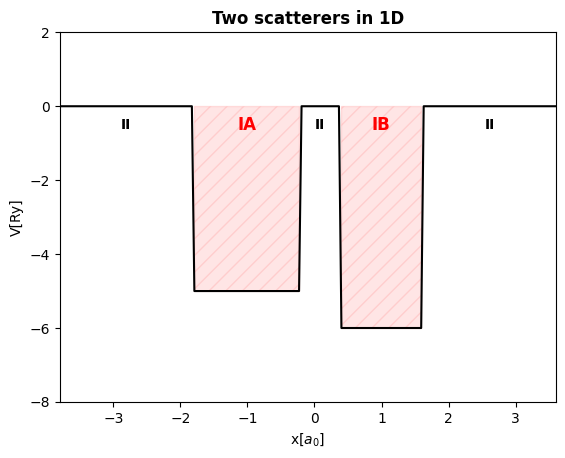

In [3]:

#! data from Butler's article ===> reference_system = 1

structure_Butler = protein_structure(energy = -3, reference_system = 1)

print("secular matrix:")
display(pd.DataFrame(structure_Butler.secular_matrix()))

V, x = structure_Butler.potential(resolution = 100)
plot_potential(x, V, structure_Butler, title = 'Two scatterers in 1D')


secular matrix:


,0,1,2,3,4,5,6,7
0,6.505497e-02+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-9.797597e-04-0.000000e+ 00j,-0.000000e+00-9.797597e- 04j,-9.599291e-07-0.000000e+ 00j,-0.000000e+00-9.599291e- 07j,-9.404998e-10-0.000000e+ 00j,-0.000000e+00-9.404998e- 10j
1,0.000000e+00+0.000000e+ 00j,-1.772134e+00+0.000000e+ 00j,-0.000000e+00+9.797597e- 04j,-9.797597e-04-0.000000e+ 00j,-0.000000e+00+9.599291e- 07j,-9.599291e-07-0.000000e+ 00j,-0.000000e+00+9.404998e- 10j,-9.404998e-10-0.000000e+ 00j
2,-9.797597e-04-0.000000e+ 00j,-0.000000e+00+9.797597e- 04j,3.234919e-02+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-9.797597e-04-0.000000e+ 00j,-0.000000e+00-9.797597e- 04j,-9.599291e-07-0.000000e+ 00j,-0.000000e+00-9.599291e- 07j
3,-0.000000e+00-9.797597e- 04j,-9.797597e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.638130e-01+0.000000e+ 00j,-0.000000e+00+9.797597e- 04j,-9.797597e-04-0.000000e+ 00j,-0.000000e+00+9.599291e- 07j,-9.599291e-07-0.000000e+ 00j
4,-9.599291e-07-0.000000e+ 00j,-0.000000e+00+9.599291e- 07j,-9.797597e-04-0.000000e+ 00j,-0.000000e+00+9.797597e- 04j,6.672481e-01+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-9.797597e-04-0.000000e+ 00j,-0.000000e+00-9.797597e- 04j
5,-0.000000e+00-9.599291e- 07j,-9.599291e-07-0.000000e+ 00j,-0.000000e+00-9.797597e- 04j,-9.797597e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-7.282442e+00+0.000000e+ 00j,-0.000000e+00+9.797597e- 04j,-9.797597e-04-0.000000e+ 00j
6,-9.404998e-10-0.000000e+ 00j,-0.000000e+00+9.404998e- 10j,-9.599291e-07-0.000000e+ 00j,-0.000000e+00+9.599291e- 07j,-9.797597e-04-0.000000e+ 00j,-0.000000e+00+9.797597e- 04j,1.280716e-01+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j
7,-0.000000e+00-9.404998e- 10j,-9.404998e-10-0.000000e+ 00j,-0.000000e+00-9.599291e- 07j,-9.599291e-07-0.000000e+ 00j,-0.000000e+00-9.797597e- 04j,-9.797597e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-2.404986e-01+0.000000e+ 00j


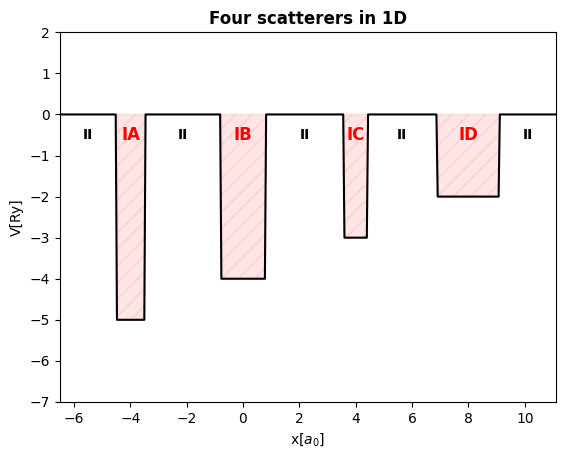

In [4]:
s1 = scatterer(r = 0.5, V = -5)
s2 = scatterer(0.8, -4)
s3 = scatterer(0.4, -3)
s4 = scatterer(1.1, -2)

s = [s1, s2, s3, s4]
x = [-4, 0, 4, 8]

structure = protein_structure(-3, s, x)

print("secular matrix:")
display(pd.DataFrame(structure.secular_matrix()))

V, x = structure.potential(resolution = 100)
plot_potential(x, V, structure, title = 'Four scatterers in 1D')

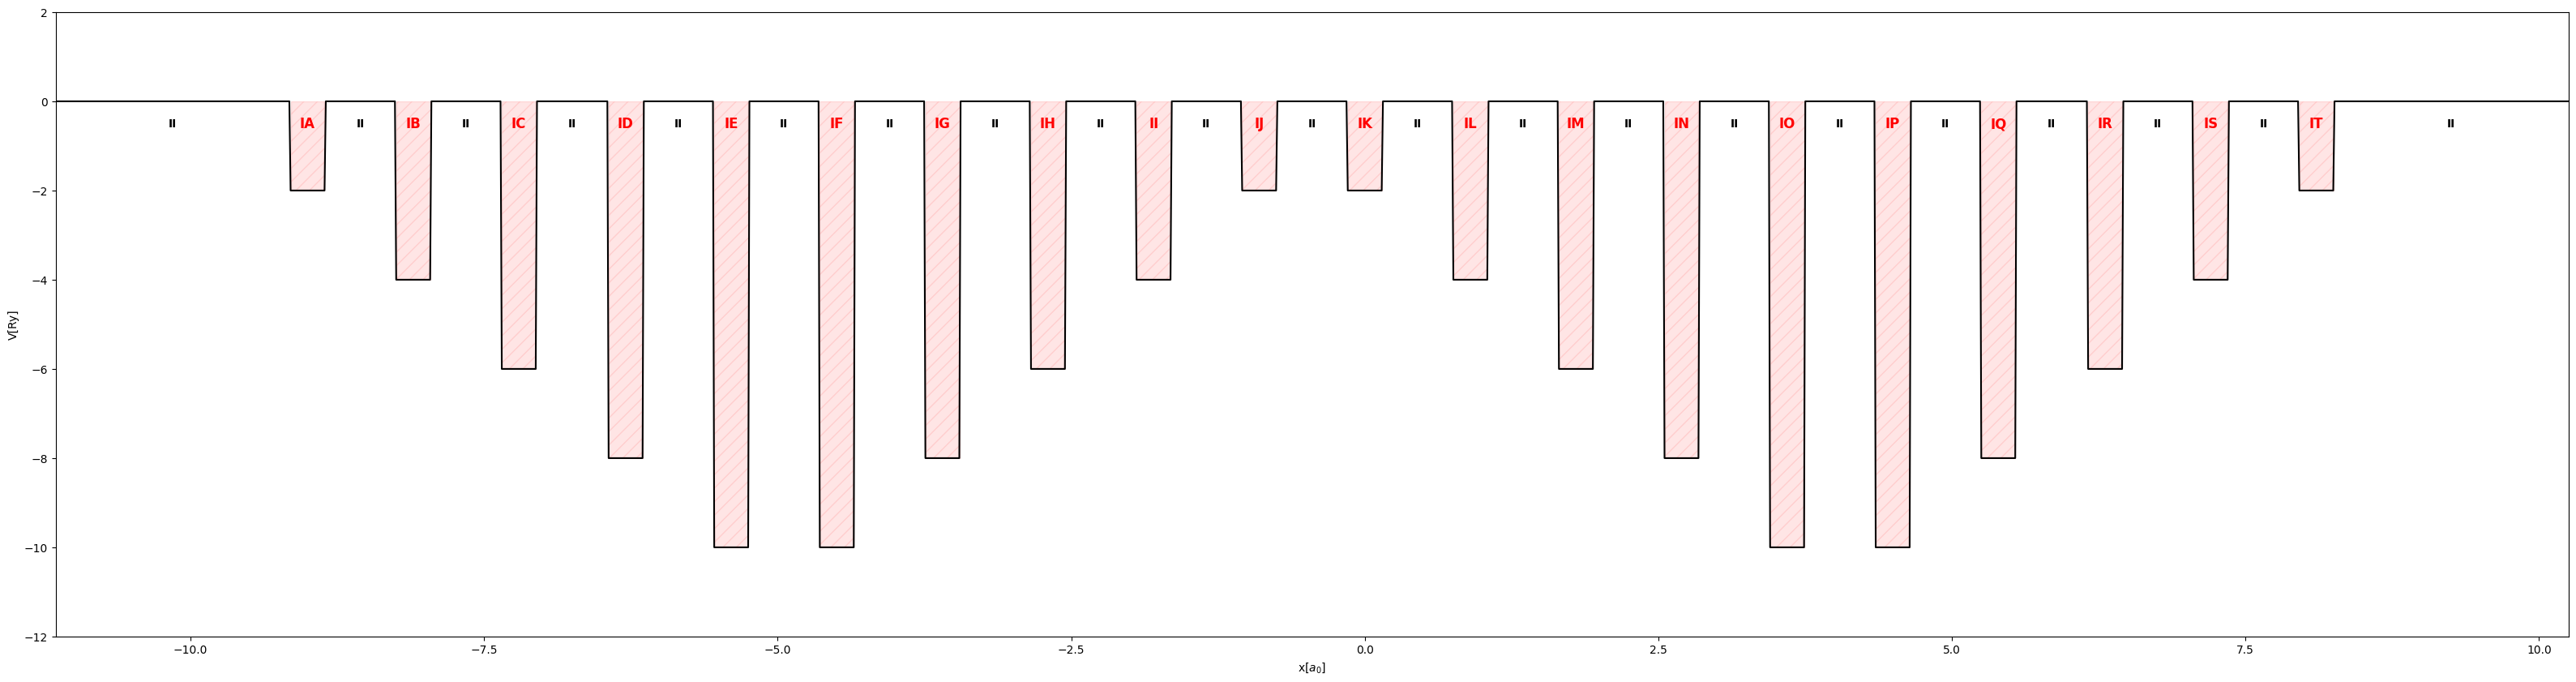

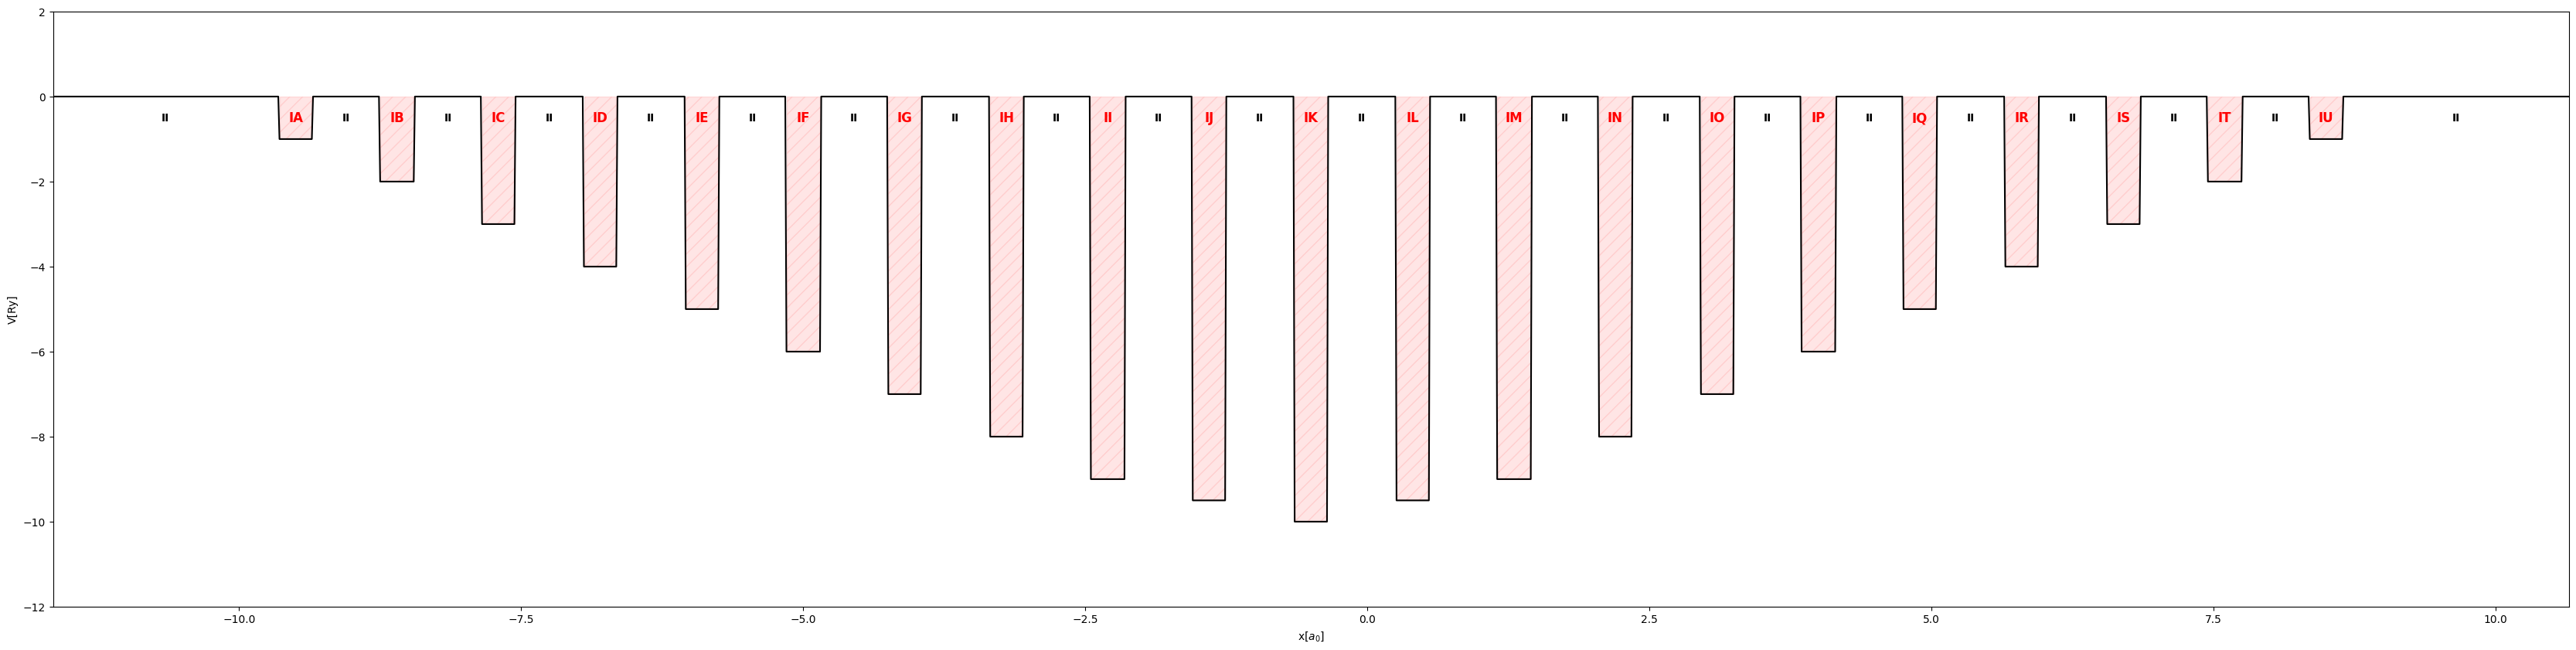

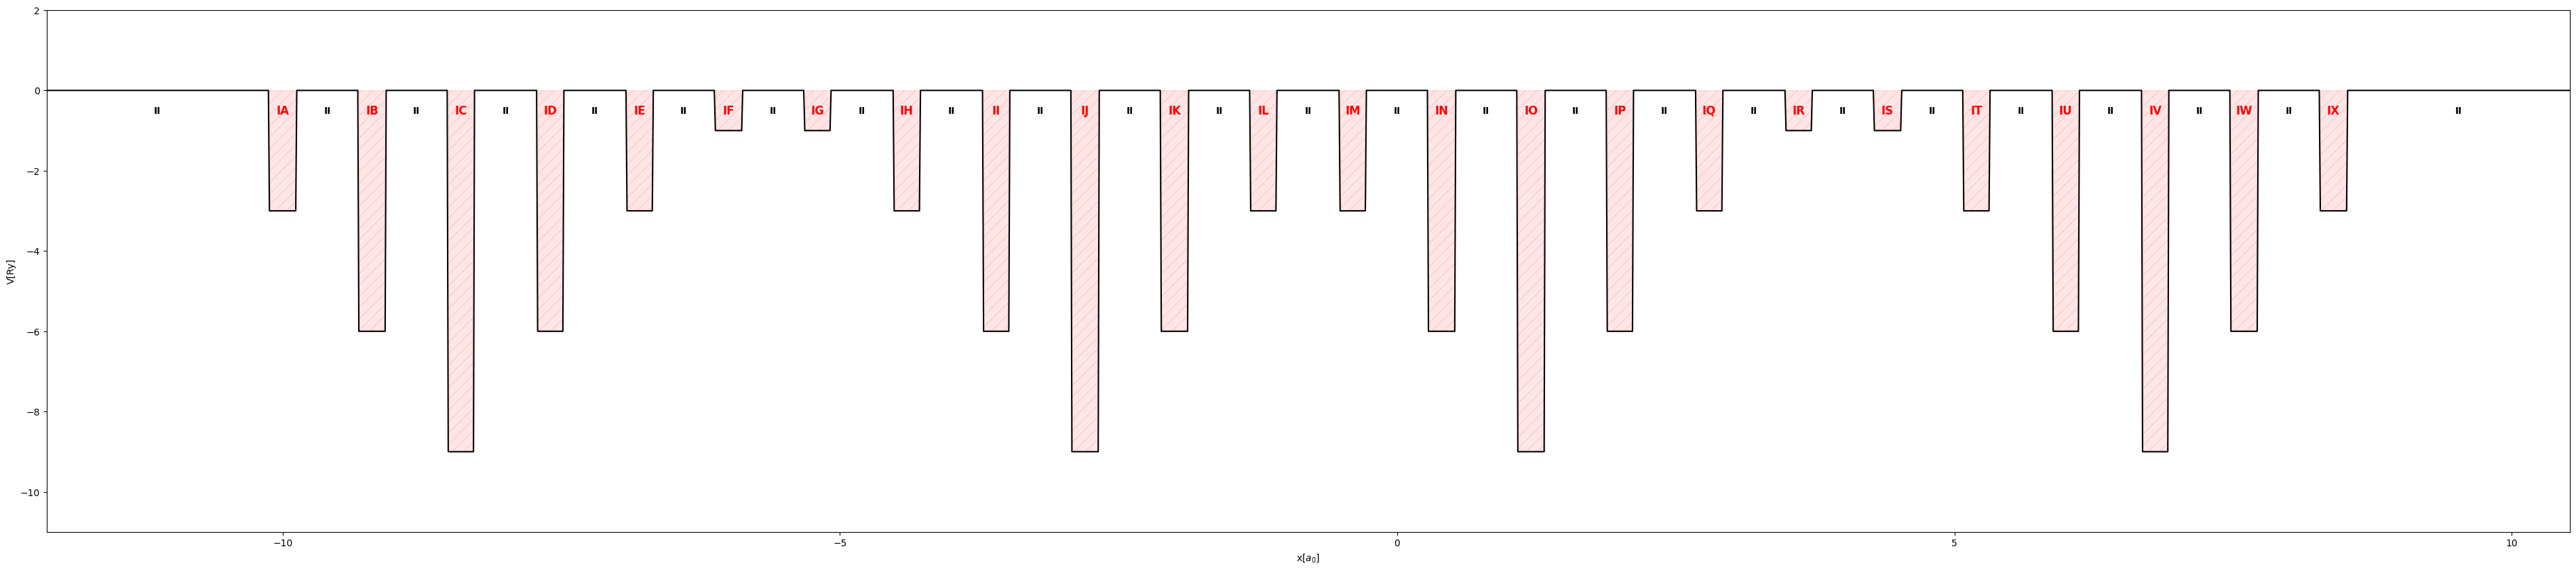

In [5]:
structure_2 =protein_structure(-3, reference_system=2)
V, x = structure_2.potential(resolution = 100)
plot_potential(x, V, structure_2)

structure_3 =protein_structure(-3, reference_system=3)
V, x = structure_3.potential(resolution = 100)
plot_potential(x, V, structure_3)

structure_4 =protein_structure(-3, reference_system=4)
V, x = structure_4.potential(resolution = 100)
plot_potential(x, V, structure_4)

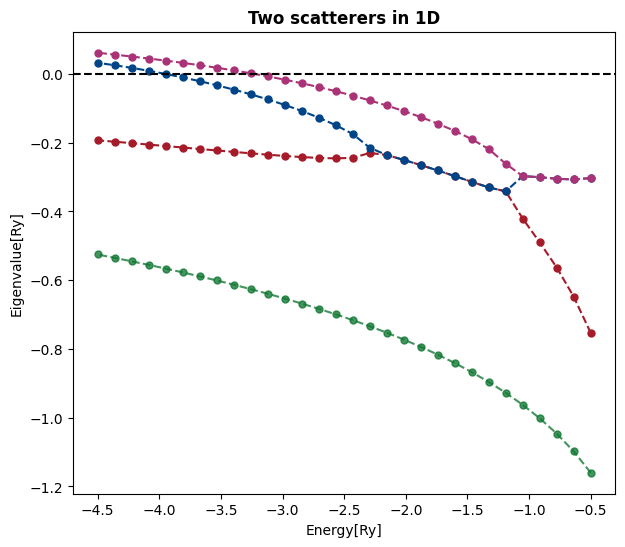

In [6]:
s = structure_Butler.scatterers
x = structure_Butler.positions

nE = 30
energies = np.linspace(-0.5, -4.5, nE)

results = Numpy_energies(energies, arr_s= s, arr_x= x)

eval_1, eval_2, eval_3, eval_4 = results 

numpy_colors = ["#117733C8", "#A61B29", "#004488", "#AA3377"]


plt.figure(figsize=(7, 6))

plt.plot(energies, eval_1, 'o--', color=numpy_colors[0], markersize=5)
plt.plot(energies, eval_2, 'o--', color=numpy_colors[1], markersize=5)
plt.plot(energies, eval_3, 'o--', color=numpy_colors[2], markersize=5)
plt.plot(energies, eval_4, 'o--', color=numpy_colors[3], markersize=5)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Eigenvalue[Ry]')
plt.xlabel('Energy[Ry]')
plt.title('Two scatterers in 1D', fontsize=12, fontweight='semibold')
plt.show()


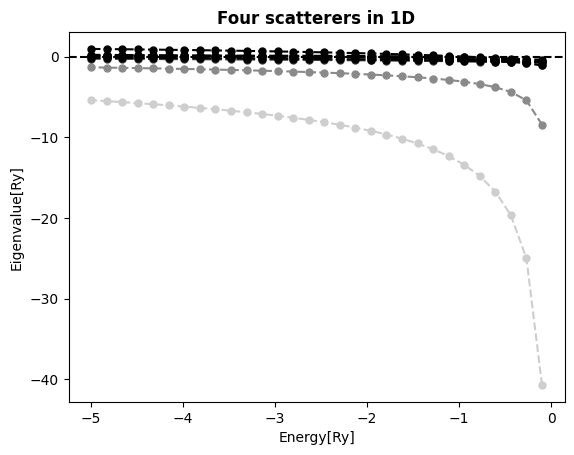

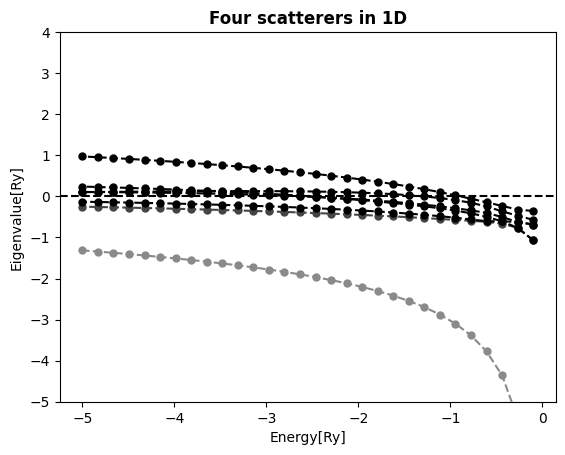

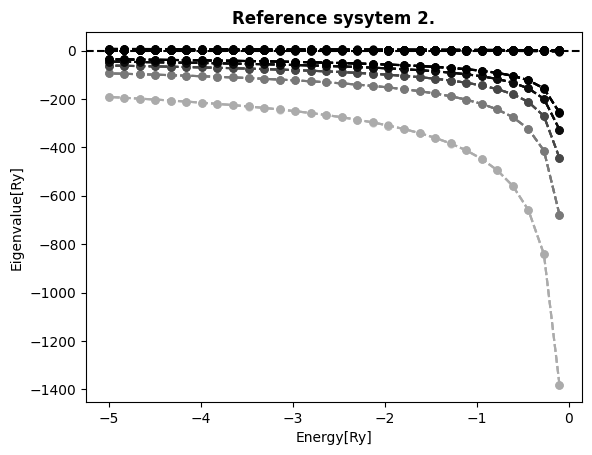

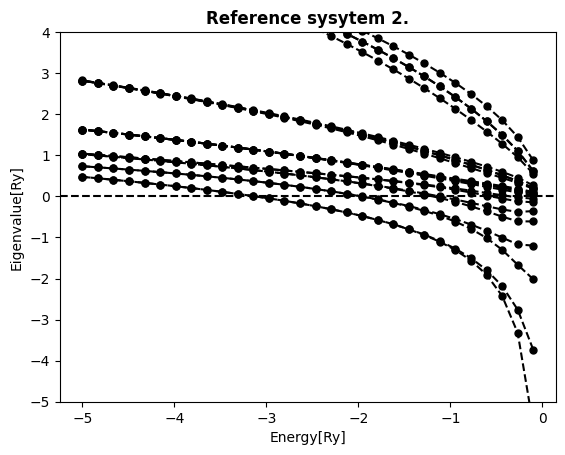

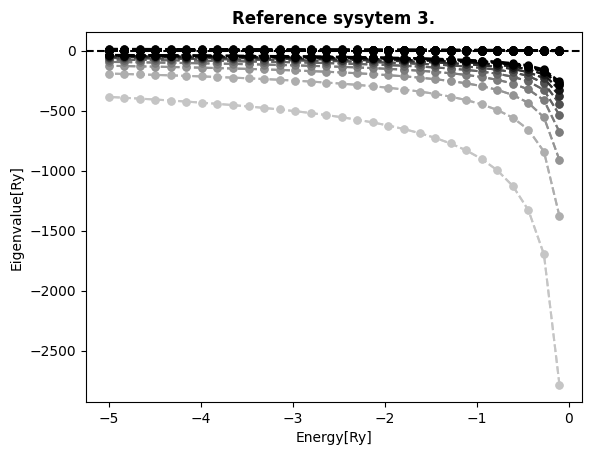

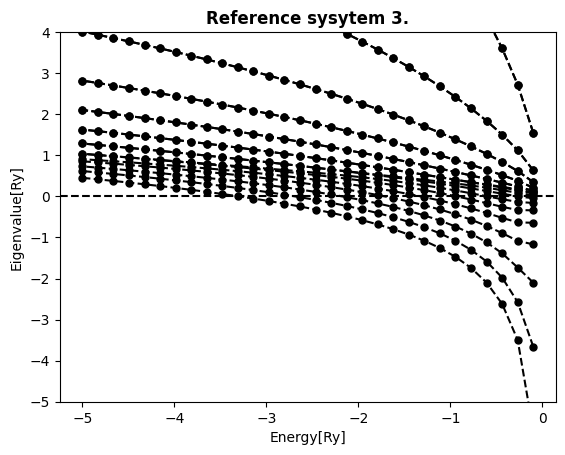

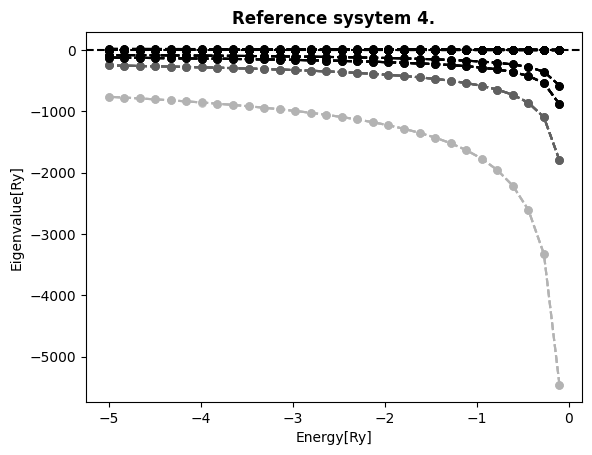

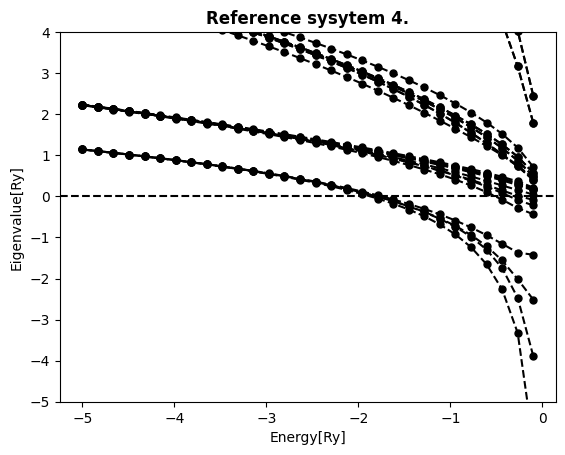

In [7]:
examples = [structure, structure_2, structure_3, structure_4]
titles = ['Four scatterers in 1D', 'Reference sysytem 2.', 'Reference sysytem 3.', 'Reference sysytem 4.']
for i_ex in range(len(examples)):
    ex = examples[i_ex]
    t = titles[i_ex]
    s = ex.scatterers
    x = ex.positions

    nE = 30
    energies = np.linspace(-0.1, -5, nE)

    results = Numpy_energies(energies, arr_s= s, arr_x= x)

    cmap = plt.cm.Greys
    num_lines = results.shape[0]  
    colors = [cmap(i) for i in np.linspace(0.3, 2, num_lines)]

    for i in range (len(results)):
        plt.plot(energies, results[i], 'o--',  markersize=5, color = colors[i])

    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel('Eigenvalue[Ry]')
    plt.xlabel('Energy[Ry]')
    plt.title(t, fontsize=12, fontweight='semibold')
    plt.show()

    for i in range (len(results)):
        plt.plot(energies, results[i], 'o--',  markersize=5, color = colors[i])

    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel('Eigenvalue[Ry]')
    plt.xlabel('Energy[Ry]')
    plt.ylim(-5, 4)
    plt.title(t, fontsize=12, fontweight='semibold')
    plt.show()

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.5000 : -3.0000,-3.228442
1,1,-4.0000 : -3.5000,-3.949616


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.5000 : -3.0000,-3.194724
1,1,-4.5000 : -4.0000,-4.139905


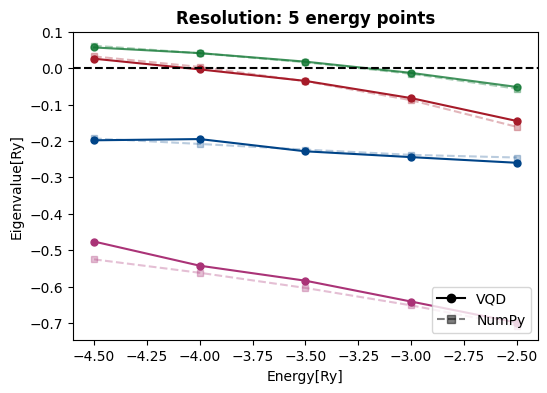

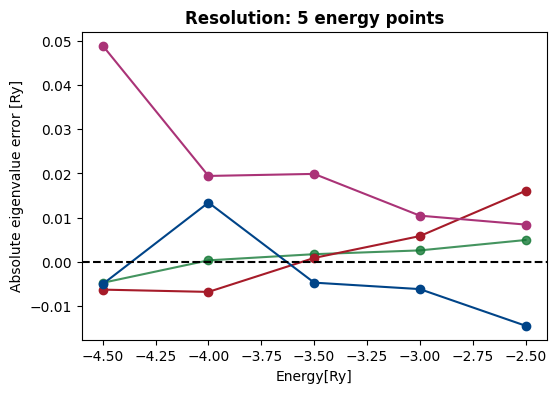

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.3889 : -3.1667,-3.228486
1,1,-4.0556 : -3.8333,-3.949877


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.3889 : -3.1667,-3.211536
1,1,-4.0556 : -3.8333,-3.942910


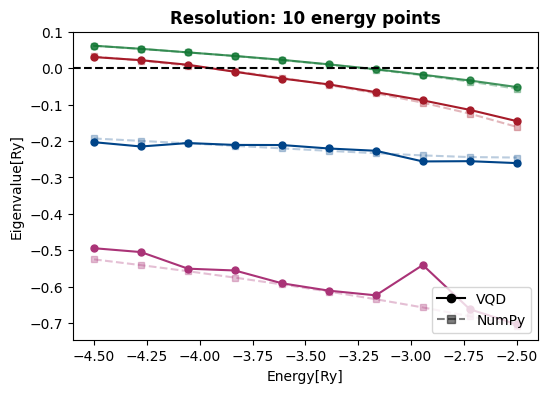

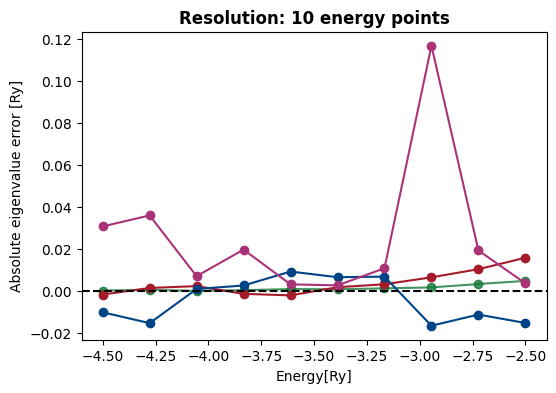

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.2368 : -3.1316,-3.228487
1,1,-3.9737 : -3.8684,-3.949901


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.2368 : -3.1316,-3.197092
1,1,-3.9737 : -3.8684,-3.923853


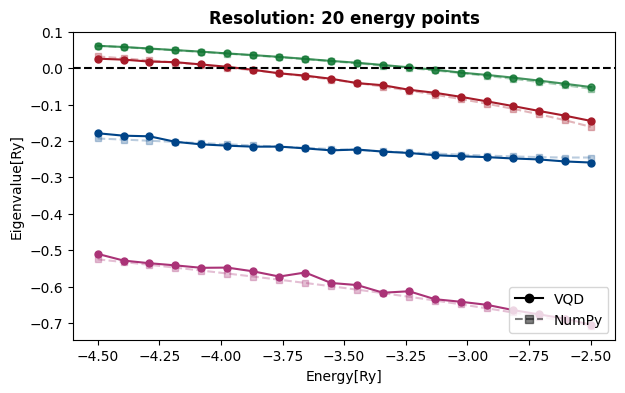

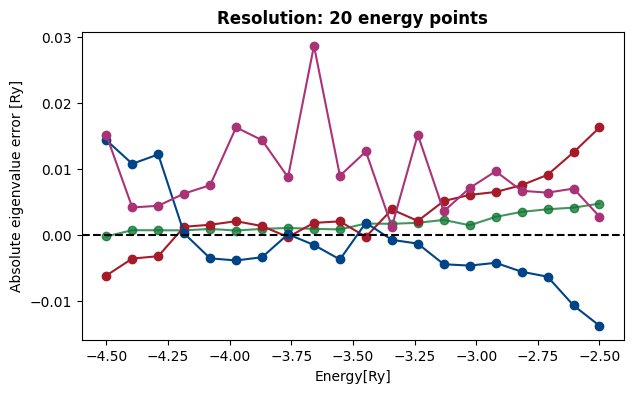

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.2692 : -3.2179,-3.228487
1,1,-3.9872 : -3.9359,-3.949902


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.2179 : -3.1667,-3.196230
1,1,-3.9872 : -3.9359,-3.960669


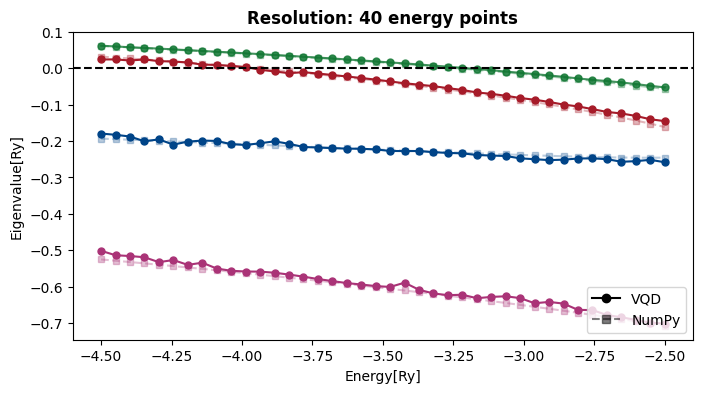

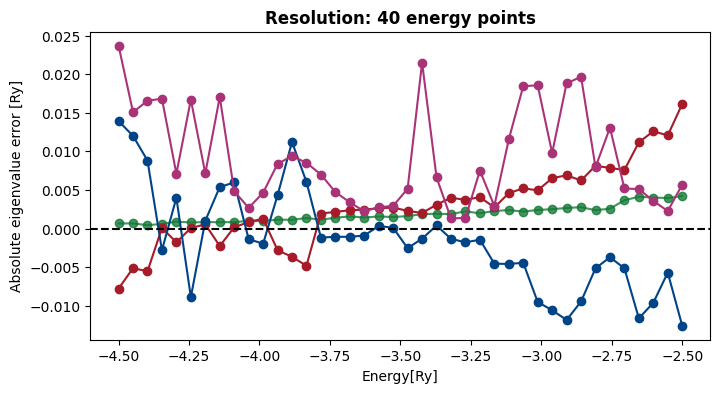

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.2342 : -3.2089,-3.228487
1,1,-3.9684 : -3.9430,-3.949902


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.2089 : -3.1835,-3.199841
1,1,-3.9937 : -3.9684,-3.975233


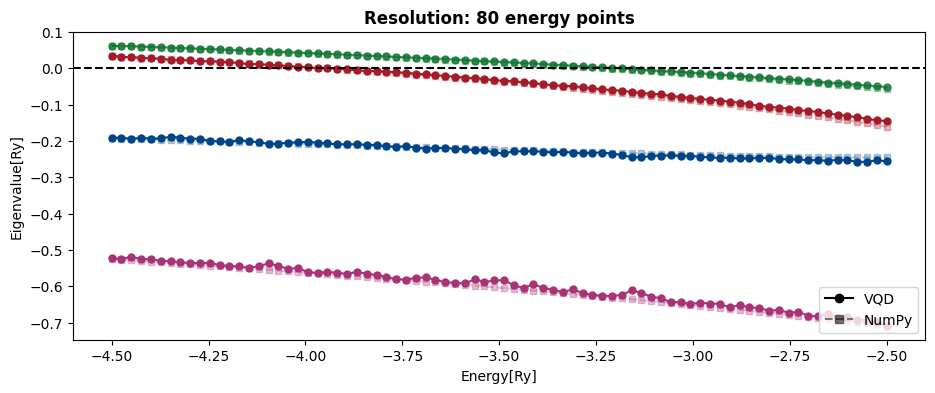

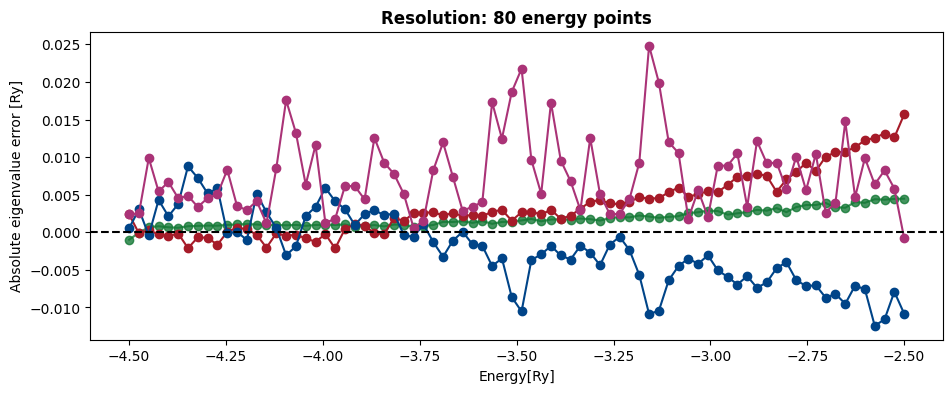

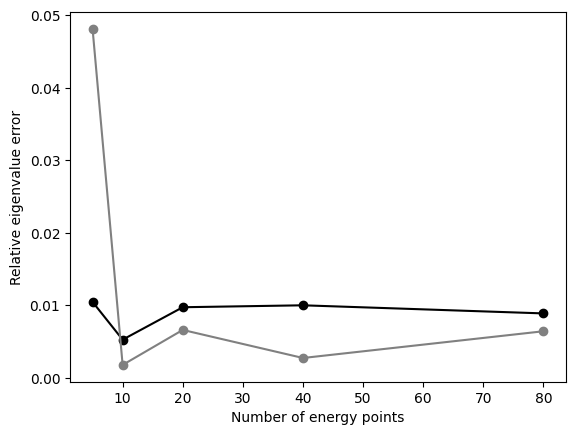

In [13]:
input_dir = "thesis_plots_data/vqd_energy_resolution/vqd_2/"
files = sorted(glob.glob(input_dir + "*.txt"))

index = 0
wyniki_e1 =[]
wyniki_e2 =[]
num_points = [5, 10, 20, 40, 80]
for file in files:

    energies, e1, e2, e3, e4, eval_1, eval_2, eval_3, eval_4 = np.loadtxt(file).T

    arr_eigen_val = []
    arr_eigen_val_NP = []
    for ev in range(0, len(e1)):
        arr_eigen_val.append(e1[ev])
        arr_eigen_val.append(e2[ev])
        arr_eigen_val.append(e3[ev])
        arr_eigen_val.append(e4[ev])

        arr_eigen_val_NP.append(eval_1[ev])
        arr_eigen_val_NP.append(eval_2[ev])
        arr_eigen_val_NP.append(eval_3[ev])
        arr_eigen_val_NP.append(eval_4[ev])

    energies_arr = []
    for i in range(4):
        energies_arr.extend(energies)

    # print(np.shape(arr_eigen_val), np.shape(energies_arr))

    print('NumPy results:')
    interpolation(len(energies), arr_eigen_val_NP, energies)

    print('VQD results:')
    wyniki = interpolation(len(energies), arr_eigen_val, energies)

    plt.close('all')

    vqd_colors = ["#117733C8", "#A61B29", "#004488", "#AA3377"]
    numpy_colors = ["#11773357", "#A61B2952", "#00448845", "#AA337750"]
    plt.figure(figsize=(6+num_points[index]//15, 4))
    plt.plot(energies, e1, 'o-', color=vqd_colors[0], markersize=5)
    plt.plot(energies, e2, 'o-', color=vqd_colors[1], markersize=5)
    plt.plot(energies, e3, 'o-', color=vqd_colors[2], markersize=5)
    plt.plot(energies, e4, 'o-', color=vqd_colors[3], markersize=5)

    plt.plot(energies, eval_1, 's--', color=numpy_colors[0], markersize=5)
    plt.plot(energies, eval_2, 's--', color=numpy_colors[1], markersize=5)
    plt.plot(energies, eval_3, 's--', color=numpy_colors[2], markersize=5)
    plt.plot(energies, eval_4, 's--', color=numpy_colors[3], markersize=5)

    custom_handles = [Line2D([0], [0], marker='o', linestyle='-', color='black', markersize=6),
                        Line2D([0], [0], marker='s', linestyle='--', color='black', markersize=6, alpha = 0.5),]



    custom_labels = ['VQD', 'NumPy']
    plt.legend(custom_handles, custom_labels, loc='lower right')

    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel('Eigenvalue[Ry]')
    plt.xlabel('Energy[Ry]')
    plt.title(f"Resolution: {num_points[index]} energy points", fontsize=12, fontweight='semibold')

    plt.show()

    plt.figure(figsize=(6+num_points[index]//15, 4))
    plt.plot(energies, e1 - eval_1, 'o-', color=vqd_colors[0])
    plt.plot(energies, e2 - eval_2, 'o-', color=vqd_colors[1])
    plt.plot(energies, e3 - eval_3, 'o-', color=vqd_colors[2])
    plt.plot(energies, e4 - eval_4, 'o-', color=vqd_colors[3])
    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel('Absolute eigenvalue error [Ry]')
    plt.xlabel('Energy[Ry]')
    plt.title(f"Resolution: {num_points[index]} energy points", fontsize=12, fontweight='semibold')
    plt.show()

    wyniki_e1.append(wyniki[0][0])
    wyniki_e2.append(wyniki[1][0])
    # print(wyniki_e1, len(wyniki_e1))

    index +=1

exact_e1 = -3.22848704
exact_e2 = -3.949901757
plt.figure()
plt.plot(num_points, np.abs((np.array(wyniki_e1)-exact_e1)/exact_e1), 'o-', color = 'black', label = '1st bound state energy')
plt.plot(num_points, np.abs((np.array(wyniki_e2)-exact_e2)/exact_e2), 'o-', color = 'gray', label = '2st bound state energy')
plt.ylabel('Relative eigenvalue error')
plt.xlabel('Number of energy points')
plt.show()

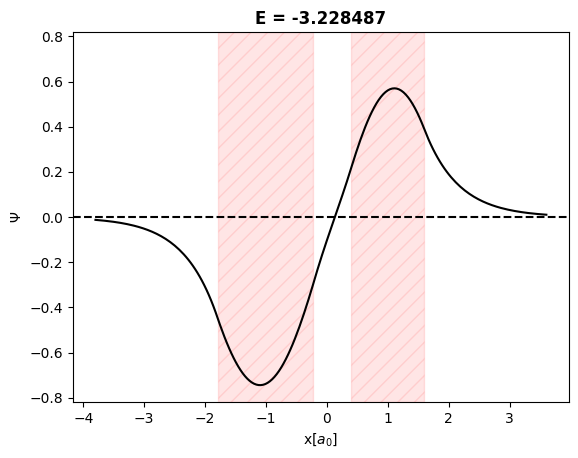

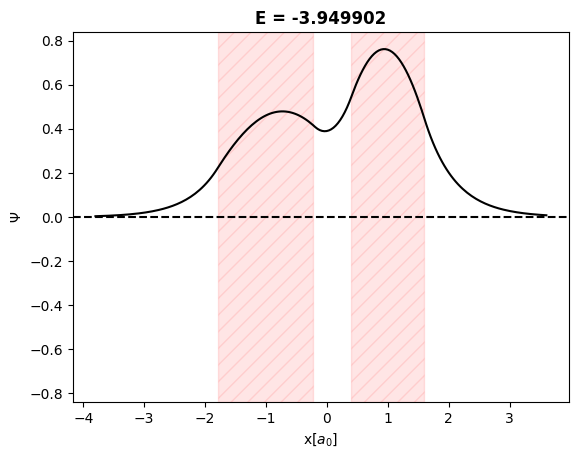

In [10]:
exact_e1 = -3.22848704
exact_e2 = -3.949901757

structure_Butler = protein_structure(energy = -3, reference_system = 1)
V, x = structure_Butler.potential(resolution = 100)

plot_wavefunction(x, V, protein_structure(exact_e1, reference_system=1))

plot_wavefunction(x, V, protein_structure(exact_e2, reference_system=1))